### Libraries.

In [1]:
import math
import os
import os
import sys
from typing import Literal, OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import scvi
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm

from sc_exp_design.constants import DataFields, LossFields, ParamsFields
from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.networks import ConditionEncoder, MLPBlock, MLPGaussianNoiseModel
from sc_exp_design.training.base import BaseTrainer
from sc_exp_design.training.callbacks import BaseCallBack
from sc_exp_design.utils import set_reproducibility

sys.path.insert(0, "../../scripts")
from fetch_data import get_log_transformed_experimental_variables
from data_utils import (
    get_one_hot_encoded_protocols,
    get_one_hot_encoded_protocol_axis
)


### Paths and constants.

In [2]:
# paths
H5AD_PATH = "/Users/lorenzo.consoli/Work/data/collab-goettgens/ds_HID01_logicle_100k_UMAP_ann.h5ad"

# columns
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]',
    'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]',
    'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]'
]
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
LOG1P_EXP_COL = ["um171_[nm]", "um729_[µm]", "scf_[ng_ml]", 
                 "butyzamide_[nm]", "o2_[%]",
                 "sr1_[nm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]"]
LOG21P_EXP_COL = ["ldl_[ng_ml]", "il3_[ng_ml]", "retinoic_acid_[µm]",]

# adata keys
X_CHANNEL_OBSM_KEY = "X_channel"
OHE_PROTOCOLS_OBS_KEY = "protocol"
OHE_PROTOCOLS_UNS_KEY = "protocol_ohe"
CONCAT_FEATS_OBSM_KEY_SUFFIX = "scatter_concat"
CONDITION_CONCAT_OBSM_KEY = "protocol_axes_concat"

# transformations options
STANDARDIZE_SCATTER_FEATURES = True
STANDARDIZE_CHANNEL_FEATURES = True
STANDARDIZE_PCs = False

# training
TRAIN_BATCH_SIZE = 256
VAL_BATCH_SIZE = 64
LR = 1e-3
NUM_GRAD_STEPS = 1_000
GRAD_STEPS_LOG_INTERVAL = 10
NUM_MC_SAMPLES = 100
NUM_GRAD_ACCUMULATIONS_STEPS=1
REG_STRENGTH = 1e-0
COND_REG_MODE = None
COND_REG_STRENGTH = 5e-3
USE_TORCHLOGP = False
EPS = 1e-9

# model
STATE_ENCODER_HIDDEN_DIMS = (128, 128)
STATE_DECODER_HIDDEN_DIMS = (128, 128)
CONDITION_ENCODER_HIDDEN_DIMS = (64, 64)
STATE_LATENT_DIM = 16
CONDITION_LATENT_DIM = 4
DEVICE = "cpu"

# scvi
SCVI_LAYER_KEY = "X_channel"
SCVI_DISPERSION = "gene" # default "gene"
SCVI_GENE_LIKELIHOOD = "normal" # default "zinb"
SCVI_USE_OBSERVED_LIB_SIZE = False # default True
SCVI_LOG_VARIATIONAL = False # default True
SCVI_NUM_EPOCHS = 50
SCVI_INFER_N_STEPS = False
SCVI_ACCELERATOR = "gpu"

# sampling
N_LATENT_SAMPLES = 5_000
N_OBS_SAMPLES = 500

# reproducibility
SEED = 42
set_reproducibility(SEED)


### Reading data.

In [3]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Handling conditions.

In [4]:
# concatenated experimental variable
adata = get_log_transformed_experimental_variables(
    adata,
    EXPERIMENTAL_COLUMNS,
    LOG1P_EXP_COL,
    LOG21P_EXP_COL,
    CONDITION_CONCAT_OBSM_KEY
)

# one hot encoding of concatenated protocol axes
adata = get_one_hot_encoded_protocols(
    adata,
    EXPERIMENTAL_COLUMNS,
    OHE_PROTOCOLS_OBS_KEY,
    OHE_PROTOCOLS_UNS_KEY
)


# one hot encoding of concatenated protocol axes
adata = get_one_hot_encoded_protocol_axis(
    adata,
    EXPERIMENTAL_COLUMNS,
    OHE_PROTOCOLS_UNS_KEY
)
adata


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'protocol_ohe', 'mtg_[µm]_protocol_ohe', 'rhflt3l_

### Splitting the data.

In [5]:
train_adata, val_adata = train_test_split(adata, test_size=0.3)
train_adata.shape, val_adata.shape

((70000, 21), (30000, 21))

### Creating representation with concatenated scatter features and normalizing features.


In [6]:
# retrieving scatter features and optionally normalizing them
X_scatter_train = train_adata.obs[SCATTER_COLUMNS].values
X_scatter_val =  val_adata.obs[SCATTER_COLUMNS].values
X_scatter_mean = X_scatter_train.mean(0)
X_scatter_std = X_scatter_train.std(0)
if STANDARDIZE_SCATTER_FEATURES:
    print("Standardizing scatter features")
    X_scatter_train = (X_scatter_train - X_scatter_mean)/X_scatter_std
    X_scatter_val = (X_scatter_val - X_scatter_mean)/X_scatter_std
assert np.isfinite(X_scatter_train).all()
assert np.isfinite(X_scatter_val).all()


# concatenating with channel features
train_adata.obsm[X_CHANNEL_OBSM_KEY] = train_adata.X
val_adata.obsm[X_CHANNEL_OBSM_KEY] = val_adata.X
X_channel_train = train_adata.X
X_channel_val = val_adata.X
X_channel_mean = X_channel_train.mean(0)
X_channel_std = X_channel_train.std(0)
if STANDARDIZE_CHANNEL_FEATURES:
    print("Standardizing channel features")
    X_channel_train = (X_channel_train - X_channel_mean)/X_channel_std
    X_channel_val = (X_channel_val - X_channel_mean)/X_channel_std
assert np.isfinite(X_channel_train).all()
assert np.isfinite(X_channel_val).all()

train_adata.X = X_channel_train
val_adata.X = X_channel_val
train_adata.obsm[f"X_channel_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_train, X_scatter_train), axis=1)
val_adata.obsm[f"X_channel_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_channel_val, X_scatter_val), axis=1)

# concatenating with PCs
X_pca_train = train_adata.obsm["X_pca"]
X_pca_val = val_adata.obsm["X_pca"]
X_pca_mean = X_pca_train.mean(0)
X_pca_std = X_pca_train.std(0)
if STANDARDIZE_PCs:
    print("Standardizing PCs")
    X_pca_train = (X_pca_train - X_pca_mean)/X_pca_std
    X_pca_val = (X_pca_val - X_pca_mean)/X_pca_std
assert np.isfinite(X_pca_train).all()
assert np.isfinite(X_pca_val).all()

train_adata.obsm["X_pca"] = X_pca_train
val_adata.obsm["X_pca"] = X_pca_val
train_adata.obsm[f"X_pca_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_pca_train, X_scatter_train), axis=1)
val_adata.obsm[f"X_pca_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"] = np.concatenate((X_pca_val, X_scatter_val), axis=1)
train_adata, val_adata

Standardizing scatter features
Standardizing channel features


/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_49566/741337475.py:15: ImplicitModificationWarning: Setting element `.obsm['X_channel']` of view, initializing view as actual.
  train_adata.obsm[X_CHANNEL_OBSM_KEY] = train_adata.X
/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_49566/741337475.py:16: ImplicitModificationWarning: Setting element `.obsm['X_channel']` of view, initializing view as actual.
  val_adata.obsm[X_CHANNEL_OBSM_KEY] = val_adata.X


(AnnData object with n_obs × n_vars = 70000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type', 'protocol'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'protocol_ohe', 'mtg_[µm]_protocol_ohe', 'rhflt

### Defining the data managers.

In [7]:
# defining dictionary for each conditioning mode settings
conditioning_mode_setting_dict = {
    "unconditional": {}, 
    "protocol_concat": {
        "perturbations": (CONDITION_CONCAT_OBSM_KEY),
        "perturbations_in_obsm": (CONDITION_CONCAT_OBSM_KEY),
        "perturbation_reps": {CONDITION_CONCAT_OBSM_KEY: CONDITION_CONCAT_OBSM_KEY},

    },
    "protocol_ohe": {
        "perturbations": (OHE_PROTOCOLS_OBS_KEY, ),
        "perturbation_reps": {OHE_PROTOCOLS_OBS_KEY: OHE_PROTOCOLS_UNS_KEY}
    },
    "protocol_axes_ohe": {
        "perturbations": EXPERIMENTAL_COLUMNS,
        "perturbation_reps": {protocol_ax: f"{protocol_ax}_{OHE_PROTOCOLS_UNS_KEY}" for protocol_ax in EXPERIMENTAL_COLUMNS}
    }
}

# initializing data managers
dm_dict = {}
reprs = ["X_channel", "X_pca", f"X_channel_{CONCAT_FEATS_OBSM_KEY_SUFFIX}", f"X_pca_{CONCAT_FEATS_OBSM_KEY_SUFFIX}"]
for repr in reprs:
    for conditioning_mode, conditioning_settings in conditioning_mode_setting_dict.items():
        dm = DataManager(
            train_adata,
            None if repr == "X_channel" else repr,
            **conditioning_settings
        )
        dm_dict[f"{repr}_{conditioning_mode}"] = dm
dm_dict.keys()

dict_keys(['X_channel_unconditional', 'X_channel_protocol_concat', 'X_channel_protocol_ohe', 'X_channel_protocol_axes_ohe', 'X_pca_unconditional', 'X_pca_protocol_concat', 'X_pca_protocol_ohe', 'X_pca_protocol_axes_ohe', 'X_channel_scatter_concat_unconditional', 'X_channel_scatter_concat_protocol_concat', 'X_channel_scatter_concat_protocol_ohe', 'X_channel_scatter_concat_protocol_axes_ohe', 'X_pca_scatter_concat_unconditional', 'X_pca_scatter_concat_protocol_concat', 'X_pca_scatter_concat_protocol_ohe', 'X_pca_scatter_concat_protocol_axes_ohe'])

### Retrieving train and validation data.

In [8]:
data_dict = {
    data_mode: {
        "train": dm.get_data(train_adata),
        "val": dm.get_data(val_adata)
    }
    for data_mode, dm in dm_dict.items()
}


### Constucting Data Loaders.

In [9]:
dl_dict = {
    data_mode: {
        "train": SequentialDataLoader(data["train"], TRAIN_BATCH_SIZE, device_id=DEVICE),
        "val": SequentialDataLoader(data["val"], VAL_BATCH_SIZE, device_id=DEVICE),
    }
    for data_mode, data in data_dict.items()
}

### Defining class for AE.

In [10]:
class VAE(torch.nn.Module):
    def __init__(
        self,
        encoder,
        decoder,
        condition_encoder=None,
        device=DEVICE,
    ):
        super().__init__()
      
        modules = {
            "encoder": encoder,
            "decoder": decoder,
        }
        if condition_encoder is not None:
            self.is_conditional = True
            modules["condition_encoder"] = condition_encoder
        else:
            self.is_conditional = False

        # store modules properly
        self.submodules = torch.nn.ModuleDict(modules)    
        self.device = device   

    def get_latent_params(
        self,
        x,
        latent_condition=None,
    ):
        # handling input for encoder
        if self.is_conditional:
            assert latent_condition is not None
            encoder_input = torch.concatenate((x, latent_condition), dim=-1)
        else:
            encoder_input = x
        return self.submodules["encoder"](encoder_input)

    def get_decoded_params(
        self,
        latent_states,
        latent_condition=None,
    ):
        # handling input for encoder
        if self.is_conditional:
            assert latent_condition is not None
            decoder_input = torch.concatenate((latent_states, latent_condition), dim=-1)
        else:
            latent_condition = None
            decoder_input = latent_states
        return self.submodules["decoder"](decoder_input)

    def encode_condition(
        self,
        condition=None,
    ):
        assert condition is not None
        return self.submodules["condition_encoder"](condition)
    
    def sample_latent_states(
        self,
        N,
        x,
        latent_condition=None,
    ):
        # encoding states
        latent_params = self.get_latent_params(x, latent_condition=latent_condition)
        return self.sample_from_params(N, latent_params)
    
    def sample_observations(
        self,
        N,
        latent_states,
        latent_condition=None,
    ):
        # encoding states
        latent_params = self.get_decoded_params(latent_states, latent_condition=latent_condition)
        return self.sample_from_params(N, latent_params)

    def sample_prior_predictive(
        self,
        n_prior_samples,
        n_likelihood_samples,
        condition=None,
    ):
        # encoding conditions
        if self.is_conditional:
            assert condition is not None
            cond_dict = {
                k: v.unsqueeze(0).repeat(n_prior_samples, *(1 for _ in v.shape)).type(torch.float32).to(self.device)  for k, v in condition.items()
            }
            latent_cond = self.encode_condition(cond_dict)
        else:
            latent_cond = None
        z_prior = torch.randn((n_prior_samples, self.submodules["encoder"].output_dim), device=self.device, dtype=torch.float32)
        x_params = self.get_decoded_params(z_prior, latent_condition=latent_cond)
        x_samples = self.sample_from_params(n_likelihood_samples, x_params)
        return {
            "z_samples": z_prior,
            "x_params": x_params,
            "x_samples": x_samples,
            "latent_cond": latent_cond
        }

    def sample_posterior_predictive(
        self,
        x,
        n_posterior_samples,
        n_likelihood_samples,
        condition=None,
    ):
        # encoding conditions
        if self.is_conditional:
            assert condition is not None
            cond_dict = {
                k: v.unsqueeze(0).repeat(n_posterior_samples, *(1 for _ in v.shape))  for k, v in condition.items()
            }
            latent_cond = self.encode_condition(cond_dict)
        else:
            latent_cond = None
        z_params = self.get_latent_params(x, latent_condition=latent_cond)
        z_posterior = self.sample_from_params(n_likelihood_samples, z_params) # m: (N, B, Z)
        x_params = self.get_decoded_params(z_posterior, latent_condition=latent_cond)
        x_samples = self.sample_from_params(n_likelihood_samples, x_params)
        return {
            "z_params": z_params,
            "z_samples": z_posterior,
            "x_params": x_params,
            "x_samples": x_samples,
            "latent_cond": latent_cond
        }

    @staticmethod
    def sample_from_params(N, params):
        # parsing parameter dictionary
        mean = params[ParamsFields.MEAN]
        cov = params[ParamsFields.COVARIANCE]

        # sampling noise and matching shapes
        noise = torch.randn((N, *mean.shape), device=mean.device, dtype=torch.float)
        mean = mean.unsqueeze(0)
        cov = cov.unsqueeze(0)
        return mean + torch.sqrt(cov)*noise


### Defining function for setting of MLP and linear projection config.

In [11]:
get_mlp_config = lambda hidden_dims, final_activation_class=torch.nn.Identity: {
    "hidden_dims": hidden_dims,
    "use_batchnorm": False,
    "use_dropout": False,
    "activation_class": torch.nn.ReLU,
    "final_activation_class": final_activation_class,
}
lm_config = lambda final_activation_class=torch.nn.Identity: get_mlp_config((), final_activation_class=final_activation_class)

# dumppy test
MLPBlock(2, 3, **get_mlp_config((16, ))), MLPBlock(2, 3, **lm_config())

(MLPBlock(
   (net): Sequential(
     (0): Sequential(
       (0): Linear(in_features=2, out_features=16, bias=True)
       (1): ReLU()
     )
     (1): Sequential(
       (0): Linear(in_features=16, out_features=3, bias=True)
       (1): Identity()
     )
   )
 ),
 MLPBlock(
   (net): Sequential(
     (0): Sequential(
       (0): Linear(in_features=2, out_features=3, bias=True)
       (1): Identity()
     )
   )
 ))

### Defining factory for setting of MLP gaussian noise models.

In [12]:
get_gaussian_config = lambda latent_dim, cov_estimation_mode, shared_repr_hidden_dims: {
    "latent_dim": latent_dim,
    "use_shared_representation": True,
    "cov_estimation_mode": cov_estimation_mode,
    "encoder_mlp_kwargs": get_mlp_config(shared_repr_hidden_dims),
    "mean_mlp_kwargs": lm_config(),
    "cov_mlp_kwargs": lm_config(final_activation_class=torch.nn.Softplus),
}
MLPGaussianNoiseModel(input_dim=2, output_dim=3, **get_gaussian_config(3, "isotropic", (16, ))) 
MLPGaussianNoiseModel(input_dim=2, output_dim=3, **get_gaussian_config(3, "isotropic", (16, )))

MLPGaussianNoiseModel(
  (encoder): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=2, out_features=16, bias=True)
        (1): ReLU()
      )
      (1): Sequential(
        (0): Linear(in_features=16, out_features=3, bias=True)
        (1): Identity()
      )
    )
  )
  (mean_net): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=3, out_features=3, bias=True)
        (1): Identity()
      )
    )
  )
  (cov_net): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=3, out_features=1, bias=True)
        (1): Softplus(beta=1.0, threshold=20.0)
      )
    )
  )
)

### Defining function for initializing condition encoder in the concatenation case.

In [13]:
get_cond_encoder_concat = lambda hidden_dims=CONDITION_ENCODER_HIDDEN_DIMS: ConditionEncoder(
    latent_dim=CONDITION_LATENT_DIM,
    layers_before_pooling={
        f"feats_{CONDITION_CONCAT_OBSM_KEY}_{CONDITION_CONCAT_OBSM_KEY}": 
        {
            "input_dim": adata.obsm[CONDITION_CONCAT_OBSM_KEY].shape[-1],
            "output_dim": CONDITION_LATENT_DIM,
            **get_mlp_config(
                hidden_dims
            )
        }
    },
    layers_after_pooling={
        "input_dim": CONDITION_LATENT_DIM,
        "output_dim": CONDITION_LATENT_DIM,
        **lm_config()
    }
)
get_cond_encoder_concat()

ConditionEncoder(
  (after_pooling): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=4, out_features=4, bias=True)
        (1): Identity()
      )
    )
  )
)

### Defining function for initializing condition encoder in the ohe protocols.


In [14]:
get_cond_encoder_ohe = lambda hidden_dims=CONDITION_ENCODER_HIDDEN_DIMS: ConditionEncoder(
    latent_dim=CONDITION_LATENT_DIM,
    layers_before_pooling={
        f"repr_{OHE_PROTOCOLS_OBS_KEY}_{OHE_PROTOCOLS_UNS_KEY}": {
            "input_dim": list(adata.uns[OHE_PROTOCOLS_UNS_KEY].values())[0].shape[-1],
            "output_dim": CONDITION_LATENT_DIM,
            **get_mlp_config(hidden_dims)
        }
    },
    layers_after_pooling={
        "input_dim": CONDITION_LATENT_DIM,
        "output_dim": CONDITION_LATENT_DIM,
        **lm_config()
    }
)
get_cond_encoder_ohe()

ConditionEncoder(
  (after_pooling): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=4, out_features=4, bias=True)
        (1): Identity()
      )
    )
  )
)

### Defining function for initializing condition encoder in the ohe protocols axes.

In [15]:
get_cond_encoder_ohe_axis = lambda hidden_dims=CONDITION_ENCODER_HIDDEN_DIMS: ConditionEncoder(
    latent_dim=CONDITION_LATENT_DIM,
    layers_before_pooling={
        f"repr_{protocol_axis}_{protocol_axis}_{protocol_axis}_{OHE_PROTOCOLS_UNS_KEY}":  {
            "input_dim": list(adata.uns[f"{protocol_axis}_{OHE_PROTOCOLS_UNS_KEY}"].values())[0].shape[-1],
            "output_dim": CONDITION_LATENT_DIM,
            **get_mlp_config(hidden_dims)
        }
        for protocol_axis in EXPERIMENTAL_COLUMNS
    },
    layers_after_pooling={
        "input_dim": CONDITION_LATENT_DIM,
        "output_dim": CONDITION_LATENT_DIM,
        **lm_config()
    }
)
get_cond_encoder_ohe_axis()

ConditionEncoder(
  (after_pooling): MLPBlock(
    (net): Sequential(
      (0): Sequential(
        (0): Linear(in_features=4, out_features=4, bias=True)
        (1): Identity()
      )
    )
  )
)

### Dummy test.

In [16]:
# dimensions
x_dim = 20
c_dim = 13
b = 32
n = 5
m = 10

# samples
x = torch.ones((b, x_dim))
c = {"cond": torch.ones(b, c_dim)}

# initializing components unconditional
encoder = MLPGaussianNoiseModel(
    input_dim=x_dim,
    output_dim=STATE_LATENT_DIM,
)
decoder = MLPGaussianNoiseModel(
    input_dim=STATE_LATENT_DIM,
    output_dim=x_dim,
)

# initializing components conditional
cencoder = MLPGaussianNoiseModel(
    input_dim=x_dim + CONDITION_LATENT_DIM,
    output_dim=STATE_LATENT_DIM,
)
cdecoder = MLPGaussianNoiseModel(
    input_dim=STATE_LATENT_DIM + CONDITION_LATENT_DIM,
    output_dim=x_dim,
)
cond_encoder = ConditionEncoder(
    latent_dim=CONDITION_LATENT_DIM,
    layers_before_pooling={
        "cond": {
            "input_dim": c_dim,
            "output_dim": CONDITION_LATENT_DIM,
        }
    },
    layers_after_pooling={"input_dim": CONDITION_LATENT_DIM, "output_dim": CONDITION_LATENT_DIM}
)

# unconditional
vae = VAE(encoder, decoder)
z = vae.sample_latent_states(n, x, latent_condition=None)
obs = vae.sample_observations(m, z, latent_condition=None)
assert z.shape == (n, b, STATE_LATENT_DIM), z.shape
assert obs.shape == (m, n, b, x_dim), obs.shape

# conditional 
cvae = VAE(cencoder, cdecoder, cond_encoder)
latent_cond = cvae.encode_condition(c)
z = cvae.sample_latent_states(n, x, latent_condition=latent_cond)
obs = cvae.sample_observations(
    m,
    z,
    latent_condition=latent_cond.unsqueeze(0).repeat(n, *[1 for _ in z.shape[1:]])
)
assert z.shape == (n, b, STATE_LATENT_DIM), z.shape
assert obs.shape == (m, n, b, x_dim), obs.shape
if latent_cond is not None:
    assert latent_cond.shape == (b, CONDITION_LATENT_DIM), latent_cond.shape


### Defining utility and loss functions.

In [17]:
def copy_to_diagonal(x, cov):
    cov_arr = torch.zeros(
        [_ for _ in cov] + [x.shape[-1], x.shape[-1]], 
        device=x.device, dtype=torch.float
    )
    idxs = torch.arange(x.shape[-1])
    cov_arr[..., idxs, idxs] = cov
    return cov_arr

def log_prob_normal_torch(x, params, eps=EPS):
    mean = params[ParamsFields.MEAN]
    cov = params[ParamsFields.COVARIANCE]
    distr = torch.distributions.MultivariateNormal(mean, (cov + eps))
    return distr.log_prob(x)

def my_log_prob_normal(x, params, eps=EPS):
    # parsing parameters dict
    mean = params[ParamsFields.MEAN]
    cov = params[ParamsFields.COVARIANCE]
    # print(f"{x.shape=}, {mean.shape=}, {cov.shape=}")

    # inverse and determinant of covariance matrix
    logDcov = torch.sum(torch.log((cov + eps)), dim=-1)
    log_z = 0.5*(mean.shape[-1] * math.log(2 * np.pi) + logDcov)
    potential = - 0.5 * torch.sum((x - mean)**2/(cov + eps), dim=-1)
    assert torch.all(torch.isfinite(log_z)), logDcov
    assert torch.all(torch.isfinite(potential))
    return potential - log_z

if USE_TORCHLOGP:
    log_prob_normal = log_prob_normal_torch
else:
    log_prob_normal = my_log_prob_normal

def Dkl_standard_normal(params, eps=EPS):
    mean = params[ParamsFields.MEAN]
    cov = params[ParamsFields.COVARIANCE]
    rv = torch.sum(1 + torch.log((cov + eps)) - mean**2 - cov, dim=-1)
    assert torch.all(torch.isfinite(rv))
    return 0.5*torch.mean(rv, dim=-1)

# quick test log prob function 
samples = torch.randn((b, STATE_LATENT_DIM))
params = {
    ParamsFields.MEAN: torch.zeros((b, STATE_LATENT_DIM)),
    ParamsFields.COVARIANCE: torch.ones((b, STATE_LATENT_DIM))
}

# quick test regularization function
dkl = Dkl_standard_normal(params)

assert len(dkl.shape) == 0, len(dkl.shape)
assert torch.all(dkl == 0), dkl

### Defining trainer.

In [18]:
class VAETrainer(BaseTrainer):
    def __init__(
        self,
        model,
        optimizer: torch.optim.Optimizer,
        lr_scheduler: torch.optim.lr_scheduler.LRScheduler | None = None,
        lr_scheduler_step: Literal["grad_step", "valid_step"] = "grad_step",
        callbacks: BaseCallBack | None = None,
        grad_steps_log_interval: int | None = GRAD_STEPS_LOG_INTERVAL,
        num_grad_accumulation_steps: int = NUM_GRAD_ACCUMULATIONS_STEPS,
        reg_strength=REG_STRENGTH,
        n_mc_samples=NUM_MC_SAMPLES,
        cond_reg_mode=COND_REG_MODE,
        cond_reg_strength=COND_REG_STRENGTH,
        eps=EPS,
    ):
        self.model = model
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.lr_scheduler_step = lr_scheduler_step
        self.callbacks = callbacks
        self.grad_steps_log_interval = grad_steps_log_interval
        self.num_grad_accumulation_steps = num_grad_accumulation_steps 
        self.reg_strength = reg_strength
        self.n_mc_samples = n_mc_samples
        self.cond_reg_mode = cond_reg_mode
        self.cond_reg_strength = cond_reg_strength
        self.eps = eps

    def _train_step(
        self,
        step_idx: int,
        batch: dict[str, torch.Tensor],
    ):
        # parsing batch
        x = batch[DataFields.STATE_DATA] # (B, D)
        condition = batch.get(DataFields.PERTURBATION_DATA, None) # (B, C)

        # encoding condition
        if condition is not None:
            latent_cond = self.model.encode_condition(condition)
        else:
            latent_cond = None
        
        # encoder and latent regularization
        q_params = self.model.get_latent_params(x, latent_condition=latent_cond) # m: (B, Z), s_i: (B, 1), s_a: (B, Z)
        z_samples = self.model.sample_from_params(self.n_mc_samples, q_params) # m: (N, B, Z)
        dkl = Dkl_standard_normal(q_params, eps=self.eps) # ()
        reg_error = 0.5*self.reg_strength*dkl
        assert len(reg_error.shape) == 0, len(reg_error.shape)
        assert torch.all(torch.isfinite(q_params[ParamsFields.MEAN]))
        assert torch.all(torch.isfinite(q_params[ParamsFields.COVARIANCE]))
        assert torch.all(q_params[ParamsFields.COVARIANCE] + self.eps != 0)
        assert torch.isfinite(reg_error)
        assert torch.all(torch.isfinite(z_samples))
    
        # optional condition regularization
        if self.cond_reg_mode is None or latent_cond is None:
            cond_reg = 0.0
        elif self.cond_reg_mode == "l1":
            cond_reg = torch.mean(
                torch.sum(
                    torch.abs(latent_cond),
                    dim=-1
                )
            )
        elif self.cond_reg_mode == "l2":
            cond_reg =  torch.mean(
                torch.sqrt(
                    torch.sum(
                        torch.square(latent_cond),
                        dim=-1
                    )
                )
            )
        cond_rec_err = self.cond_reg_strength*cond_reg
        if isinstance(cond_reg, torch.Tensor):
            cond_reg = cond_reg.item()

        # decoder and reconstruction
        if latent_cond is not None:
            latent_cond=latent_cond.unsqueeze(0).repeat(self.n_mc_samples, *[1 for _ in z_samples.shape[1:]])
        p_params = self.model.get_decoded_params(
            z_samples,
            latent_condition=latent_cond 
        ) # m: (B, D), s_i: (B, 1), s_a: (B, D)
        if USE_TORCHLOGP:
            p_params[ParamsFields.COVARIANCE] = copy_to_diagonal(x, p_params[ParamsFields.COVARIANCE])
            log_px = log_prob_normal(x.unsqueeze(0).unsqueeze(0), p_params)
        else:
            log_px = log_prob_normal(x.unsqueeze(0).unsqueeze(0), p_params)
        rec_error = torch.mean(log_px)

        assert len(rec_error.shape) == 0, len(rec_error.shape)
        assert torch.all(torch.isfinite(p_params[ParamsFields.MEAN]))
        assert torch.all(torch.isfinite(p_params[ParamsFields.COVARIANCE]))
        assert torch.all(p_params[ParamsFields.COVARIANCE] + self.eps != 0)
        assert torch.all(torch.isfinite(z_samples))
        assert torch.all(torch.isfinite(x))
        assert torch.isfinite(rec_error)

        # aggregating loss and returning it
        loss = - rec_error - reg_error + cond_rec_err
        return loss, {LossFields.LOSS: loss.item(), "dkl": -dkl.item(), "rec_error": -rec_error.item(), "cond_reg": cond_reg, "grad_step": step_idx}

    def _validation_step(
        self,
        batch: dict[str, torch.Tensor],
    ) -> tuple[torch.Tensor]:
        """"""
        # predictions, target = ..., ...
        # return predictions, target
        raise NotImplementedError


### 

### Defining function for initializing models for each data modeling strategy.

In [19]:
def get_vae(
    state_dim,
    data_mode,
    cov_estimation_mode,
    enc_hidden_dims=STATE_ENCODER_HIDDEN_DIMS,
    dec_hidden_dims=STATE_DECODER_HIDDEN_DIMS,
    device=DEVICE
):
    cond_encoder = None
    if "protocol_concat" in data_mode:
        cond_encoder = get_cond_encoder_concat().to(device)
    if "protocol_ohe" in data_mode:
        cond_encoder = get_cond_encoder_ohe().to(device)
    if "protocol_axes_ohe" in data_mode:
        cond_encoder = get_cond_encoder_ohe_axis().to(device)

    # isotropic case
    encoder = MLPGaussianNoiseModel(
        input_dim=state_dim if cond_encoder is None else state_dim + CONDITION_LATENT_DIM, output_dim=STATE_LATENT_DIM,
        **get_gaussian_config(STATE_LATENT_DIM, cov_estimation_mode, enc_hidden_dims)
    ).to(device)
    decoder = MLPGaussianNoiseModel(
        input_dim=STATE_LATENT_DIM if cond_encoder is None else STATE_LATENT_DIM + CONDITION_LATENT_DIM, output_dim=state_dim,
        **get_gaussian_config(state_dim, cov_estimation_mode, dec_hidden_dims)
    ).to(device)
    return VAE(encoder, decoder, condition_encoder=cond_encoder)

### Initializing the models.

In [20]:
models_dict = {}
for data_mode, dl in tqdm(dl_dict.items()):
    train_dl = dl["train"]
    state_dim = train_dl.data.state_data.shape[-1]
    models_dict[f"{data_mode}_isotropic"] = get_vae(state_dim, data_mode, "isotropic").to(DEVICE)
    models_dict[f"{data_mode}_anisotropic"] = get_vae(state_dim, data_mode, "anisotropic").to(DEVICE)
models_dict.keys()

100%|██████████| 16/16 [00:00<00:00, 314.08it/s]


dict_keys(['X_channel_unconditional_isotropic', 'X_channel_unconditional_anisotropic', 'X_channel_protocol_concat_isotropic', 'X_channel_protocol_concat_anisotropic', 'X_channel_protocol_ohe_isotropic', 'X_channel_protocol_ohe_anisotropic', 'X_channel_protocol_axes_ohe_isotropic', 'X_channel_protocol_axes_ohe_anisotropic', 'X_pca_unconditional_isotropic', 'X_pca_unconditional_anisotropic', 'X_pca_protocol_concat_isotropic', 'X_pca_protocol_concat_anisotropic', 'X_pca_protocol_ohe_isotropic', 'X_pca_protocol_ohe_anisotropic', 'X_pca_protocol_axes_ohe_isotropic', 'X_pca_protocol_axes_ohe_anisotropic', 'X_channel_scatter_concat_unconditional_isotropic', 'X_channel_scatter_concat_unconditional_anisotropic', 'X_channel_scatter_concat_protocol_concat_isotropic', 'X_channel_scatter_concat_protocol_concat_anisotropic', 'X_channel_scatter_concat_protocol_ohe_isotropic', 'X_channel_scatter_concat_protocol_ohe_anisotropic', 'X_channel_scatter_concat_protocol_axes_ohe_isotropic', 'X_channel_scatte

### Mapping each model to its optimizer and trainers.

In [21]:
trainers_dict = {}
for model_id, model in models_dict.items():
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    trainers_dict[model_id] = VAETrainer(
        model,
        optimizer=optimizer,
        grad_steps_log_interval=GRAD_STEPS_LOG_INTERVAL
    )

### Fitting each model.

Fitting model X_channel_unconditional_isotropic (0/32)
Fitting model X_channel_unconditional_anisotropic (1/32)
Fitting model X_channel_protocol_concat_isotropic (2/32)


Loss: 21.1587: 100%|██████████| 1000/1000 [02:56<00:00,  5.67it/s]
/var/folders/p4/lyzkxmgs697cq8dyh_h0yh0c0000gn/T/ipykernel_49566/3441176106.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Fitting model X_channel_protocol_concat_anisotropic (3/32)


Loss: 14.5000: 100%|██████████| 1000/1000 [03:11<00:00,  5.23it/s]


Fitting model X_channel_protocol_ohe_isotropic (4/32)
Fitting model X_channel_protocol_ohe_anisotropic (5/32)
Fitting model X_channel_protocol_axes_ohe_isotropic (6/32)
Fitting model X_channel_protocol_axes_ohe_anisotropic (7/32)
Fitting model X_pca_unconditional_isotropic (8/32)
Fitting model X_pca_unconditional_anisotropic (9/32)
Fitting model X_pca_protocol_concat_isotropic (10/32)
Fitting model X_pca_protocol_concat_anisotropic (11/32)
Fitting model X_pca_protocol_ohe_isotropic (12/32)
Fitting model X_pca_protocol_ohe_anisotropic (13/32)
Fitting model X_pca_protocol_axes_ohe_isotropic (14/32)
Fitting model X_pca_protocol_axes_ohe_anisotropic (15/32)
Fitting model X_channel_scatter_concat_unconditional_isotropic (16/32)
Fitting model X_channel_scatter_concat_unconditional_anisotropic (17/32)
Fitting model X_channel_scatter_concat_protocol_concat_isotropic (18/32)


Loss: 26.7704: 100%|██████████| 1000/1000 [02:24<00:00,  6.93it/s]


Fitting model X_channel_scatter_concat_protocol_concat_anisotropic (19/32)


Loss: 18.1489: 100%|██████████| 1000/1000 [02:52<00:00,  5.80it/s]


Fitting model X_channel_scatter_concat_protocol_ohe_isotropic (20/32)
Fitting model X_channel_scatter_concat_protocol_ohe_anisotropic (21/32)
Fitting model X_channel_scatter_concat_protocol_axes_ohe_isotropic (22/32)
Fitting model X_channel_scatter_concat_protocol_axes_ohe_anisotropic (23/32)
Fitting model X_pca_scatter_concat_unconditional_isotropic (24/32)
Fitting model X_pca_scatter_concat_unconditional_anisotropic (25/32)
Fitting model X_pca_scatter_concat_protocol_concat_isotropic (26/32)
Fitting model X_pca_scatter_concat_protocol_concat_anisotropic (27/32)
Fitting model X_pca_scatter_concat_protocol_ohe_isotropic (28/32)
Fitting model X_pca_scatter_concat_protocol_ohe_anisotropic (29/32)
Fitting model X_pca_scatter_concat_protocol_axes_ohe_isotropic (30/32)
Fitting model X_pca_scatter_concat_protocol_axes_ohe_anisotropic (31/32)


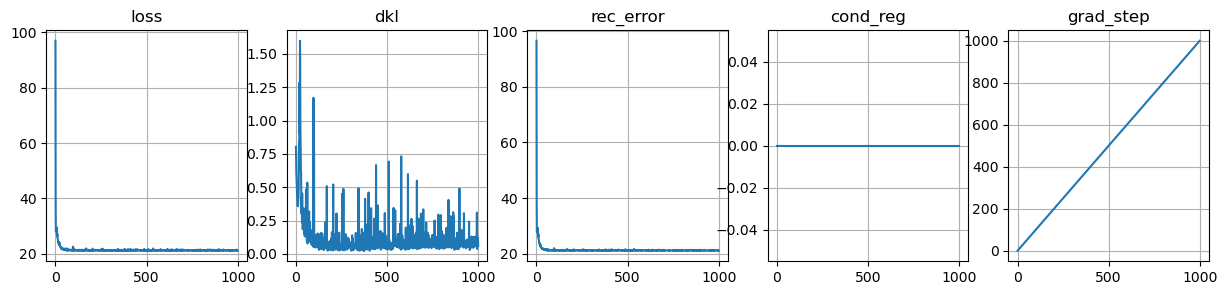

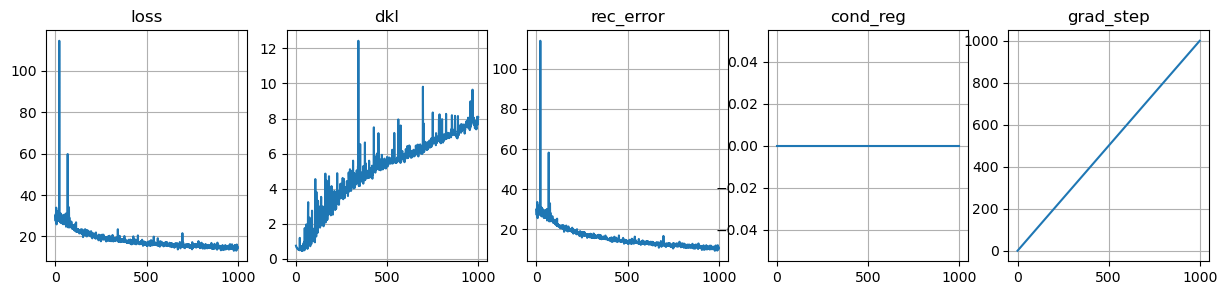

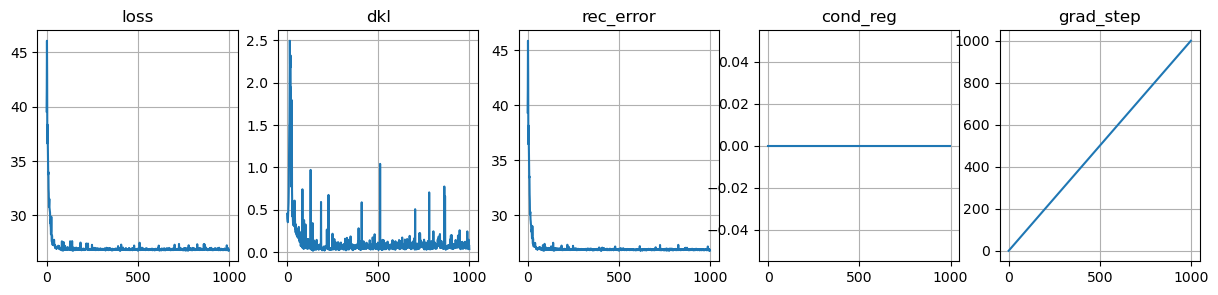

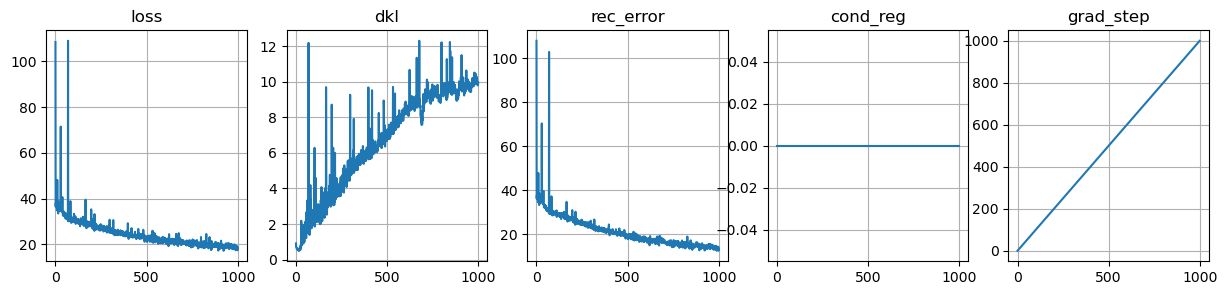

: 

In [ ]:
for midx, (model_id, trainer) in enumerate(trainers_dict.items()):
    # info message
    print(f"Fitting model {model_id} ({midx}/{len(trainers_dict)})")

    if ("channel" not in model_id) or ("protocol_concat" not in model_id):
        continue

    dl_id = "_".join(model_id.split("_")[: -1])
    dls = dl_dict[dl_id]
    train_dl = dls["train"]
    val_dl = dls["val"]

    trainer.fit(
        NUM_GRAD_STEPS,
        train_dl,
    )
    fig, axes = trainer.plot_training_logs(
        keys_to_plot=trainer.training_logs.keys(),
        figsize=(15, 3)
    )
    for ax in axes:
        ax.grid(True)
    fig.show()

### Sampling from prior predictive distribution.

In [ ]:
# retrieving unique protocols
unique_protocols = np.unique(train_adata.obsm[CONDITION_CONCAT_OBSM_KEY], axis=0)

# iterating over each model and storing the sampling results
prior_pred_results_dict = {}
prior_pred_results_list = []
for midx, (model_id, model) in enumerate(models_dict.items()):

    # info message
    print(f"Sampling with model {model_id} ({midx}/{len(trainers_dict)})")

    # iterating over each condition and storing results for model
    pbar = tqdm(range(unique_protocols.shape[0]))
    model_results_dict = {}
    for cidx, cond in enumerate(unique_protocols):
        # handling condition shape
        cond = torch.from_numpy(cond).to(DEVICE).type(torch.float)
        #cond = cond.unsqueeze(0).repeat(N_LATENT_SAMPLES, 1)
        cond_dict = {f"feats_{CONDITION_CONCAT_OBSM_KEY}_{CONDITION_CONCAT_OBSM_KEY}": cond}
        
        # sampling from prior predictive distribution
        prior_pred_results = model.sample_prior_predictive(
            N_LATENT_SAMPLES,
            N_OBS_SAMPLES,
            condition=cond_dict,
        )
        z_prior = prior_pred_results["z_samples"]
        x_params = prior_pred_results["x_params"]
        x_samples = prior_pred_results["x_samples"]
        latent_cond = prior_pred_results["latent_cond"]
        if latent_cond is not None:
            print(f"{z_prior.shape=}, {x_samples.shape=}, {latent_cond.shape=}")
        else:
            print(f"{z_prior.shape=}, {x_samples.shape=}")

        # storing the results
        model_results = {
            "prior_samples": z_prior.detach().cpu().numpy(),
            "x_params": {k:v.detach().cpu().numpy() for k, v in x_params.items()},
            "x_samples": x_samples.detach().cpu().numpy(),
            "cond_dict": {k:v.detach().cpu().numpy() for k, v in cond_dict.items()},
            "latent_cond": latent_cond if latent_cond is None else latent_cond.detach().cpu().numpy(),
            "cidx": cidx,
            "model_id": model_id,
        }
        model_results_dict[cidx] = model_results
        prior_pred_results_list.append(model_results)
        pbar.update()
    prior_pred_results_dict[model_id] = model_results_dict

Sampling with model X_channel_unconditional_isotropic (0/32)


  1%|▏         | 1/77 [00:00<00:54,  1.39it/s]

z_prior.shape=torch.Size([5000, 16]), x_samples.shape=torch.Size([500, 5000, 21])


  3%|▎         | 2/77 [00:01<00:52,  1.44it/s]

z_prior.shape=torch.Size([5000, 16]), x_samples.shape=torch.Size([500, 5000, 21])


...

z_prior.shape=torch.Size([5000, 16]), x_samples.shape=torch.Size([500, 5000, 21]), latent_cond.shape=torch.Size([5000, 4])


z_prior.shape=torch.Size([5000, 16]), x_samples.shape=torch.Size([500, 5000, 21]), latent_cond.shape=torch.Size([5000, 4])


z_prior.shape=torch.Size([5000, 16]), x_samples.shape=torch.Size([500, 5000, 21]), latent_cond.shape=torch.Size([5000, 4])


z_prior.shape=torch.Size([5000, 16]), x_samples.shape=torch.Size([500, 5000, 21]), latent_cond.shape=torch.Size([5000, 4])


 84%|████████▍ | 65/77 [01:49<03:23, 16.99s/it]

### Defining function for plotting channel-wise KDE.

In [ ]:
int2antibody = {
    idx: train_adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}

def plot_kde_channels(data_real, data_gen=None, title="", standardize=True, mean=None, std=None):
    if standardize:
        assert mean is not None
        assert std is not None
        assert mean.shape[-1] == data_real.shape[-1], f"{mean.shape=} {data_real.shape=}"
        data_real = data_real*std + mean
    fig, axes = plt.subplots(1, data_real.shape[1], figsize=(45, 5))
    fig.suptitle(f"X {title}")
    for idx in range(data_real.shape[1]):
        antibody = int2antibody[idx]
        sns.kdeplot(data_real[idx], ax=axes[idx], color="blue")
        if data_gen is not None:
            sns.kdeplot(data_gen[idx], ax=axes[idx], color="red")
        axes[idx].grid(True)
        axes[idx].set_title(antibody)
    axes[idx].legend()
    fig.show()

### Visualizing generated samples in umap and channel feat space.

In [ ]:
adata_gen_dict = {}
for model_id, model_results in prior_pred_results_dict.items():
    for cidx, cresults in model_results.items():
        # parsing results dictionary
        x_samples = cresults["x_samples"]
        cond = cresults["cond_dict"][f"feats_{CONDITION_CONCAT_OBSM_KEY}_{CONDITION_CONCAT_OBSM_KEY}"]

        # retrieving mean samples
        mean_x_samples = x_samples.mean(0)

        # retrieving validation samples generated under same protocol
        is_current_protocol = np.full((val_adata.shape[0], ), False, dtype=bool)
        is_current_protocol_idx = np.argwhere(np.all(val_adata.obsm[CONDITION_CONCAT_OBSM_KEY] == unique_protocols[cidx], axis=-1))[:, 0]
        is_current_protocol[is_current_protocol_idx] = True

        # constructing generated adata, computing pca, neighbors and umap
        X_val_std = val_adata.X
        if STANDARDIZE_CHANNEL_FEATURES:
            print("Inverse Standardization.")
            X_val = X_channel_mean + X_channel_std*X_val_std
            mean_x_samples = X_channel_mean + X_channel_std*mean_x_samples
        else:
            X_val = X_val_std
        adata_gen = sc.AnnData(
            X=np.concatenate((X_val, mean_x_samples), axis=0),
            obs={
                "dataset_type": ["real" for _ in range(len(val_adata))] + ["generated" for _ in range(mean_x_samples.shape[0])],
                "is_current_protocol": is_current_protocol.tolist() + [True for _ in range(mean_x_samples.shape[0])],
            },
        )
        adata_gen.obs["is_true_protocol"] = (adata_gen.obs["dataset_type"] == "real") & (adata_gen.obs["is_current_protocol"] == True)
        # plotting embeddings
        sc.pp.pca(adata_gen)
        sc.pp.neighbors(adata_gen)
        sc.tl.umap(adata_gen)
        adata_gen_dict[f"{model_id}_{cidx}"] = adata_gen
        
        # plotting embeddings        
        sc.pl.embedding(adata_gen, "umap", color=["dataset_type", "is_current_protocol", "is_true_protocol"])
        plot_kde_channels(
            X_val_std,
            data_gen=mean_x_samples,
            title=f"",
            standardize=STANDARDIZE_CHANNEL_FEATURES,
            mean=X_channel_mean,
            std=X_channel_std,
        )
        plot_kde_channels(
            X_val_std[is_current_protocol_idx],
            data_gen=mean_x_samples,
            title=f"",
            standardize=STANDARDIZE_CHANNEL_FEATURES,
            mean=X_channel_mean,
            std=X_channel_std,
        )

### Sampling from posterior predictive distribution.

### Fitting implementation from `scvi-tools`.

In [ ]:
# preparing data
ctrain_adata = train_adata.copy()
ctrain_adata.layers[SCVI_LAYER_KEY] = ctrain_adata.X
assert np.isnan(ctrain_adata.layers[SCVI_LAYER_KEY]).sum() == 0
assert np.isfinite(ctrain_adata.layers[SCVI_LAYER_KEY]).all()


# preparing model
scvi.model.SCVI.setup_anndata(ctrain_adata, layer=SCVI_LAYER_KEY)
model = scvi.model.SCVI(
    adata=ctrain_adata,
    n_hidden=STATE_ENCODER_HIDDEN_DIMS[0],
    n_layers=len(STATE_ENCODER_HIDDEN_DIMS),
    n_latent=STATE_LATENT_DIM,
    dispersion=SCVI_DISPERSION,
    use_observed_lib_size=SCVI_USE_OBSERVED_LIB_SIZE,
    gene_likelihood=SCVI_GENE_LIKELIHOOD,
    log_variational=SCVI_LOG_VARIATIONAL,
)
plan_kwargs ={
    "optimizer": "Adam",
    "lr": LR,
}

# retrieving number of gradient steps and fitting the model
if SCVI_INFER_N_STEPS:
    n_samples = ctrain_adata.n_obs
    steps_per_epoch = math.ceil(n_samples / TRAIN_BATCH_SIZE)
    max_steps = SCVI_NUM_EPOCHS * steps_per_epoch
    print(f"Fitting SCVI for {max_steps} steps")
    model.train(
        max_steps=max_steps,
        accelerator=SCVI_ACCELERATOR,
        batch_size=TRAIN_BATCH_SIZE,
        plan_kwargs=plan_kwargs
    )
else:
    num_epochs = SCVI_NUM_EPOCHS
    print(f"Fitting SCVI for {SCVI_NUM_EPOCHS} epochs")
    model.train(
        max_epochs=num_epochs,
        accelerator=SCVI_ACCELERATOR,
        batch_size=TRAIN_BATCH_SIZE,
        plan_kwargs=plan_kwargs
    )


# displaying loss history
history = model.history
plt.figure(figsize=(3,3))
plt.plot(history['train_loss_step'], label='Train ELBO')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("scVI Training Progress")
plt.grid(True)
plt.legend()
plt.show()

### Sampling from SCVI prior predictive distribution.


In [ ]:
type(model.module.decoder)

In [ ]:
# Sample from prior z ~ N(0, I)
z = torch.randn((N_LATENT_SAMPLES, STATE_LATENT_DIM), device=model.device)
l = torch.zeros((N_LATENT_SAMPLES, 1) , device=model.device)

# Decode to get parameters of likelihood
decoder_out = model.module.decoder(SCVI_DISPERSION, z, l, ...)

# The decoder returns scale (mean), dispersion, and maybe dropout params
px = model.module._get_likelihood_parameters(decoder_out)

# Since gene_likelihood="gaussian", px contains mean and variance
px_mu = px["px_mu"]       # shape [n_cells, n_genes]
px_var = px["px_var"]     # shape [n_cells, n_genes]

# Sample from Gaussian likelihood
x_samples = torch.normal(mean=px_mu, std=torch.sqrt(px_var))

# Move to CPU / NumPy
x_samples = x_samples.detach().cpu().numpy()

print("Shape of prior predictive samples:", x_samples.shape)


### Sampling from SCVI posterior predictive distribution.

In [ ]:
model.module.decoder.forward??